In [1]:
# Cell 1: imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Optional: set plotting style
# plt.style.use('seaborn-whitegrid')  # uncomment if desired

# File path to the CSV (adjust if needed)
csv_path = 'dark_tower_sales_demographics.csv'

In [4]:
# Cell 2: load dataset
df = pd.read_csv(csv_path)

# Quick look
df.head()

,country,year,units_sold,revenue_usd,cost_of_goods_sold_usd,profit_margin_pct,avg_price_per_unit_usd,demographic_male_pct,demographic_female_pct,demographic_age_18_34_pct,demographic_age_35_54_pct,demographic_age_55_plus_pct
0,US,2020,95000,1425000,712500,50.0,15.00,55,45,35,40,25
1,UK,2020,33000,495000,247500,50.0,15.00,50,50,30,45,25
2,US,2021,110000,1760000,880000,50.0,16.00,53,47,36,39,25
3,UK,2021,39000,598500,299250,50.0,15.35,48,52,32,44,24
4,US,2022,120000,1920000,960000,50.0,16.00,52,48,34,41,25


In [5]:
# Cell 3: basic validation
print("Columns:", df.columns.tolist())
print("\nMissing values per column:")
print(df.isna().sum())

# Check that demographic percentages roughly sum to 100 for genders and age bands
df['gender_sum'] = df['demographic_male_pct'] + df['demographic_female_pct']
df['age_sum'] = (df['demographic_age_18_34_pct'] +
                 df['demographic_age_35_54_pct'] +
                 df['demographic_age_55_plus_pct'])

print("\nDemographic sums (should be close to 100):")
print(df[['country', 'year', 'gender_sum', 'age_sum']])

Columns: ['country', 'year', 'units_sold', 'revenue_usd', 'cost_of_goods_sold_usd', 'profit_margin_pct', 'avg_price_per_unit_usd', 'demographic_male_pct', 'demographic_female_pct', 'demographic_age_18_34_pct', 'demographic_age_35_54_pct', 'demographic_age_55_plus_pct']

Missing values per column:
country                        0
year                           0
units_sold                     0
revenue_usd                    0
cost_of_goods_sold_usd         0
profit_margin_pct              0
avg_price_per_unit_usd         0
demographic_male_pct           0
demographic_female_pct         0
demographic_age_18_34_pct      0
demographic_age_35_54_pct      0
demographic_age_55_plus_pct    0
dtype: int64

Demographic sums (should be close to 100):
  country  year  gender_sum  age_sum
0      US  2020         100      100
1      UK  2020         100      100
2      US  2021         100      100
3      UK  2021         100      100
4      US  2022         100      100
5      UK  2022         100

In [6]:
# Cell 4: add extra metrics
df['gross_profit_usd'] = df['revenue_usd'] - df['cost_of_goods_sold_usd']
df['margin_pct_calc'] = df['gross_profit_usd'] / df['revenue_usd'] * 100

# Check consistency with the provided margin_pct
df[['country', 'year', 'profit_margin_pct', 'margin_pct_calc']].head()

,country,year,profit_margin_pct,margin_pct_calc
0,US,2020,50.0,50.0
1,UK,2020,50.0,50.0
2,US,2021,50.0,50.0
3,UK,2021,50.0,50.0
4,US,2022,50.0,50.0


In [7]:
# Cell 5: summary statistics
summary_by_country = df.groupby('country').agg(
    total_units_sold=('units_sold', 'sum'),
    total_revenue_usd=('revenue_usd', 'sum'),
    avg_margin_pct=('profit_margin_pct', 'mean'),
    avg_price_per_unit_usd=('avg_price_per_unit_usd', 'mean')
).reset_index()

summary_by_country

,country,total_units_sold,total_revenue_usd,avg_margin_pct,avg_price_per_unit_usd
0,UK,159000,2464500,50.0,15.4625
1,US,450000,7105000,50.0,15.7500


In [8]:
# Cell 6: year-over-year change in units sold by country
df_sorted = df.sort_values(['country', 'year']).copy()
df_sorted['units_yoy_pct'] = df_sorted.groupby('country')['units_sold'].pct_change() * 100

df_sorted[['country', 'year', 'units_sold', 'units_yoy_pct']]

,country,year,units_sold,units_yoy_pct
1,UK,2020,33000,NaN
3,UK,2021,39000,18.181818
5,UK,2022,42000,7.692308
7,UK,2023,45000,7.142857
0,US,2020,95000,NaN
2,US,2021,110000,15.789474
4,US,2022,120000,9.090909
6,US,2023,125000,4.166667


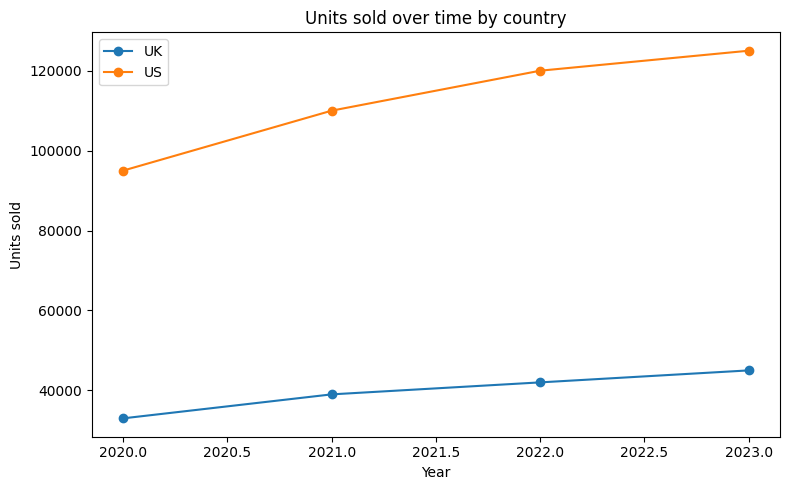

In [9]:
# Cell 7: plot units sold over time for each country
fig, ax = plt.subplots(figsize=(8,5))

for country, group in df_sorted.groupby('country'):
    ax.plot(group['year'], group['units_sold'], marker='o', label=country)

ax.set_title('Units sold over time by country')
ax.set_xlabel('Year')
ax.set_ylabel('Units sold')
ax.legend()
plt.tight_layout()
plt.show()

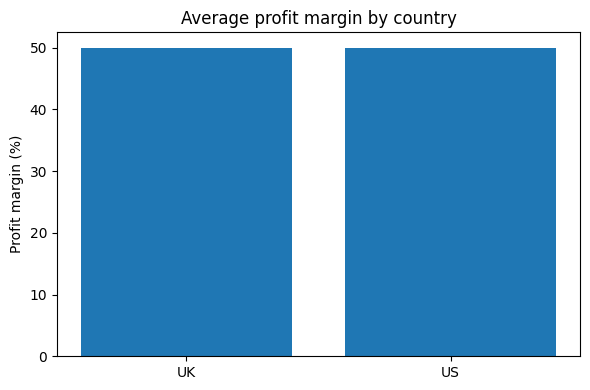

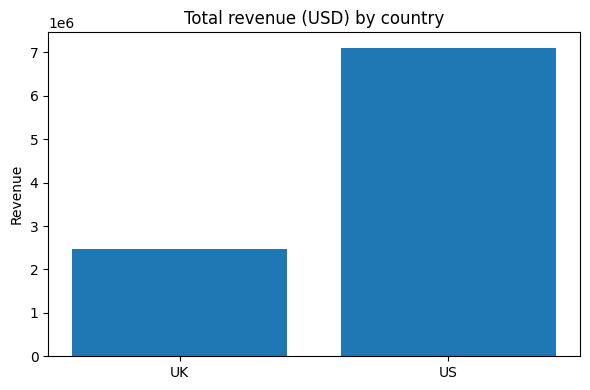

In [10]:
# Cell 8: bar chart of avg profit margin by country
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(summary_by_country['country'], summary_by_country['avg_margin_pct'])
ax.set_title('Average profit margin by country')
ax.set_ylabel('Profit margin (%)')
plt.tight_layout()
plt.show()

# Optional: revenue comparison
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(summary_by_country['country'], summary_by_country['total_revenue_usd'])
ax.set_title('Total revenue (USD) by country')
ax.set_ylabel('Revenue')
plt.tight_layout()
plt.show()

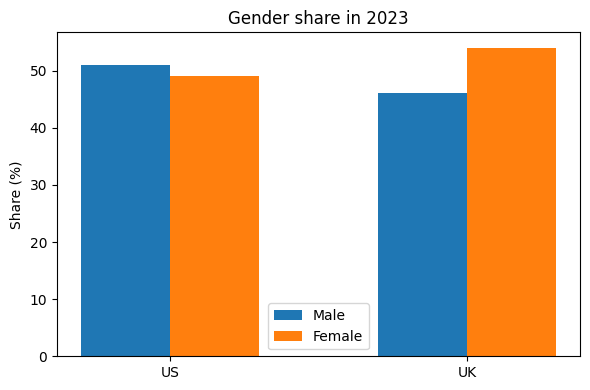

In [11]:
# Cell 9: demographic share example for latest year
latest_year = df['year'].max()
df_latest = df[df['year'] == latest_year]

# Example: gender share for US vs UK in latest year
labels = ['Male', 'Female']
x = np.arange(len(df_latest))  # US, UK

male_shares = df_latest['demographic_male_pct'].values
female_shares = df_latest['demographic_female_pct'].values

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(x - 0.15, male_shares, width=0.3, label='Male')
ax.bar(x + 0.15, female_shares, width=0.3, label='Female')

ax.set_xticks(x)
ax.set_xticklabels(df_latest['country'])
ax.set_ylabel('Share (%)')
ax.set_title(f'Gender share in {latest_year}')
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
# Cell 10: save a cleaned/augmented version
output_path = 'dark_tower_sales_demographics_cleaned.csv'
df.to_csv(output_path, index=False)
print(f"Cleaned data saved to {output_path}")

Cleaned data saved to dark_tower_sales_demographics_cleaned.csv
